# Practical session 3 - Brownian motion, Fourier transform

Students (pair):
 - [Antoine CORBY](https://github.com/antoinecorby)
 - [Astyan MARTIN](https://github.com/AstyanM)

In [1]:
%load_ext autoreload
%autoreload 2

## <a name="ex1">Exercise 1: Brownian motion</a>

This first exercise consists in generating a Brownian motion on the closed unit ball $\mathcal{B}(\mathbf{0}, 1) = \{ \mathbf{x} \mid \Vert \mathbf{x} \Vert  \leq 1\}$, focusing first on the 2-D case. The Brownian motion is a random walk with independent, identically distributed Gaussian increments, appearing for instance in thermodynamics and statistical mechanics (to model the evolution of a large particle in a medium composed of a large number of small particles, ...). It is also connected to the diffusion process (Einstein).

Let $N \in \mathbb{N}^*$, $\delta > 0$, and $\mathbf{x} = (x_1, x_2) \in  \mathcal{B}(\mathbf{0}, 1)$. The first $N$ steps of a 2-D discrete-time Brownian motion $W$ can be generated as follows

\begin{align*}
    W_0 &= \mathbf{x}, \\
    %
    (\forall n \in \{1, \dotsc, N-1 \}), \quad W_n &= W_{n−1} + \sqrt{\delta} G_n, \quad G_n \sim \mathcal{N}(\mathbf{0}, \mathbf{I}),
\end{align*}

where $\mathcal{N}(\mathbf{0}, \mathbf{I})$ is a Gaussian distribution with mean $\mathbf{0}$ and identity covariance matrix.

1. Define a random generator `rng`, set to a known state for reproducibility (see session 2).

**Answer:**

In [2]:
import numpy as np

rng = np.random.default_rng(seed=8)

2. Implement a function `brownian_motion(niter, x, step, rng)` which

    - simulates $W$ until it reaches the boundary of $\mathcal{B}(\mathbf{0}, 1)$, using a maximum of $N$ iterations (`niter`), a starting point $\mathbf{x} \in \mathcal{B}(\mathbf{0}, 1)$ (`x`) and step-size $\delta$ (`step`);
    - interpolates linearly between the two last positions to determine the points $W^*$ where the trajectory crosses the boundary (if applicable);
    - returns both the whole random walk $W$ and, if appropriate, the point at the intersection between the last segment of the trajectory and $\mathcal{B}(\mathbf{0}, 1)$.
 
> Hint: 
> - you can easily derive a closed form expression for $W^*$, observing that $\Vert W^* \Vert^2= 1$ and $W^* \in [W_{n-1}, W_n]$. 
> - you can also take a look at [`np.roots`](https://numpy.org/doc/stable/reference/generated/numpy.roots.html?highlight=roots#numpy.roots) if needed.

> Recall of the Linear Interpolation (LERP) for $n$-dimensional vectors:
> - Clearly, $\vec{D}=\alpha \vec{C}$ with $\alpha \in [0, 1]$ and hence $\vec{P}-\vec{B}= \alpha (\vec{A}-\vec{B})$ which is equivalent to $\vec{P}= (1-\alpha) \vec{B} + \alpha \vec{A}$. 
![alternatvie text](img/for_Course.png)

**Answer:**

In [3]:
def brownian_motion(niter, x, step, rng):
    """
    Simulates a Brownian motion until it hits the boundary of the unit ball.
    """
    path = [np.array(x, dtype=float)]
    intersection_point = None
    
    for _ in range(niter):
        increment = np.sqrt(step) * rng.standard_normal(2)
        next_pos = path[-1] + increment
        
        if np.linalg.norm(next_pos) >= 1.0:
            # Interpolate linearly to find intersection point
            A = path[-1]
            B = next_pos
            d = B - A
            
            # We want ||A + alpha * d||^2 = 1 with alpha in [0, 1]
            # ||d||^2 * alpha^2 + 2<A, d> * alpha + ||A||^2 - 1 = 0
            a = np.dot(d, d)
            b = 2 * np.dot(A, d)
            c = np.dot(A, A) - 1.0
            
            roots = np.roots([a, b, c])
            # Select the real root in [0, 1]
            alpha = [r for r in roots if 0 <= r <= 1][0]
            
            intersection_point = A + alpha * d
            path.append(intersection_point)
            break
        else:
            path.append(next_pos)
            
    return np.array(path), intersection_point

intersection = brownian_motion(1000, [0, 0], 0.01, rng)[1]
print("Intersection point:", intersection, "of norm", np.linalg.norm(intersection))

Intersection point: [-0.83623551  0.54837047] of norm 1.0


3. Diplay the trajectory of a Brownian motion starting from $\mathbf{x} = (0.2, 0.4)$, using $\delta = 10^{-2}$, $N = 1000$. Display the unit circle on the same figure, and highlight the intersection with the boundary of the domain (whenever it exists).

> Hint: to draw the unit disk, you can use for instance:
> ```python
> circle = plt.Circle((0,0), 1)
> fig, ax = plt.subplots()
> plt.xlim(-1.25,1.25)
> plt.ylim(-1.25,1.25)
> plt.grid(linestyle = "--", zorder = 1)
> ax.set_aspect(1)
> ax.add_artist(circle)
> ```

**Answer:**

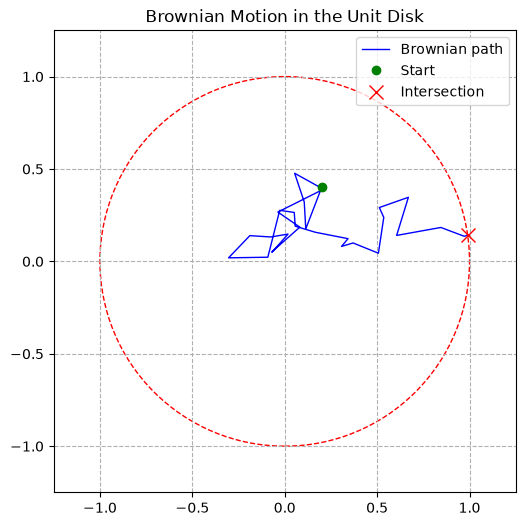

In [4]:
import matplotlib.pyplot as plt
niter = 1000
step = 1e-2
x0 = np.array([0.2, 0.4])

path, intersection_point = brownian_motion(niter, x0, step, rng)

fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0,0), 1, fill=False, color='red', linestyle='--')
ax.add_artist(circle)

ax.plot(path[:, 0], path[:, 1], 'b-', linewidth=1, label='Brownian path')
ax.plot(path[0, 0], path[0, 1], 'go', label='Start')

if intersection_point is not None:
    ax.plot(intersection_point[0], intersection_point[1], 'rx', markersize=10, label='Intersection')

ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.grid(linestyle="--", zorder=1)
ax.set_aspect(1)
ax.legend()
plt.title("Brownian Motion in the Unit Disk")
plt.show()

4. Represent, on the same figure, 4 other trajectories of $W$ with the same parameters.

**Answer:**

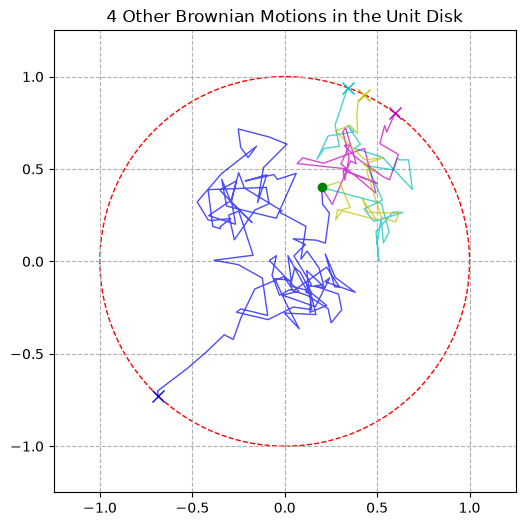

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0,0), 1, fill=False, color='red', linestyle='--')
ax.add_artist(circle)
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.grid(linestyle="--", zorder=1)
ax.set_aspect(1)

colors = ['b', 'c', 'm', 'y']
for i in range(4):
    path, intersection_point = brownian_motion(niter, x0, step, rng)
    ax.plot(path[:, 0], path[:, 1], color=colors[i], linewidth=1, alpha=0.7)
    if intersection_point is not None:
        ax.plot(intersection_point[0], intersection_point[1], color=colors[i], marker='x', markersize=8)

ax.plot(x0[0], x0[1], 'go', label='Start')
plt.title("4 Other Brownian Motions in the Unit Disk")
plt.show()

5. [Bonus] Generalize the procedure to a $M$-dimensional Brownian motion, $M > 2$.

**Answer:**

In [6]:
def brownian_motion_md(niter, x, step, rng):
    """
    Simulates a M-dimensional Brownian motion until it hits the boundary of the unit ball.
    """
    path = [np.array(x, dtype=float)]
    intersection_point = None
    dim = len(x)
    
    for _ in range(niter):
        increment = np.sqrt(step) * rng.standard_normal(dim)
        next_pos = path[-1] + increment
        
        if np.linalg.norm(next_pos) >= 1.0:
            # Interpolate linearly to find intersection point
            A = path[-1]
            B = next_pos
            d = B - A
            
            # We want ||A + alpha * d||^2 = 1 with alpha in [0, 1]
            # ||d||^2 * alpha^2 + 2<A, d> * alpha + ||A||^2 - 1 = 0
            a = np.dot(d, d)
            b = 2 * np.dot(A, d)
            c = np.dot(A, A) - 1.0
            
            roots = np.roots([a, b, c])
            # Select the real root in [0, 1]
            alpha = [r for r in roots if 0 <= r <= 1][0]
            
            intersection_point = A + alpha * d
            path.append(intersection_point)
            break
        else:
            path.append(next_pos)
            
    return np.array(path), intersection_point

intersection = brownian_motion_md(1000, [0, 0, 0, 0], 0.01, rng)[1]
print("Intersection point:", intersection, "of norm", np.linalg.norm(intersection))

Intersection point: [ 0.12935418  0.55471988 -0.45673988  0.68333157] of norm 1.0


---
## <a name="ex2">Exercise 2: 2D Fourier transform, ideal low-pass filter and linear convolution</a>

In this exercise, we explore the use of the 2-dimensional Fourier transform to filter an image, and convolve it with a blurring kernel.

1\. Load and display one of the images contained in the `img/` folder. The image will be denoted by $\mathbf{X} \in \mathbb{R}^{M_1 \times N_1}$ in the rest of this exercise.

**Answer:**

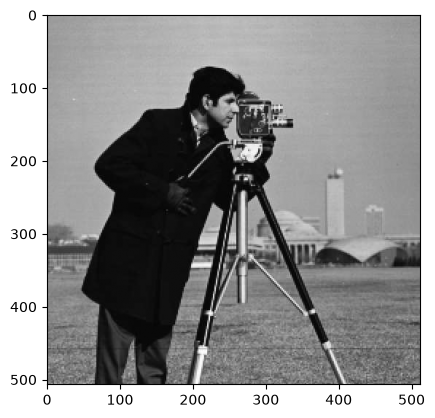

In [11]:
import matplotlib.image as mpimg

image_path = 'img/cameraman.png'
X = mpimg.imread(image_path)
plt.imshow(X, cmap='gray')

2\. Let $\mathcal{F}$ denote the 2D discrete Fourier transform. Compute $|\mathcal{F}(\mathbf{X})|^2$, the spectrum of the image $\mathbf{X} \in \mathbb{R}^{M_1 \times N_1}$ (i.e., the term-wise squared absolute value of its Fourier transform) loaded in 1. Display the result in logarithmic scale.

a) In this representation, where is the pixel of the spectrum associated with the null frequency located?
    
b) Take a look at the documentation of `np.fft.fftshift`. Use it to ensure that the null frequency is located at the center of the image. 

**Answer:**

a) The null frequency (DC component) is initially located at the top-left pixel (0, 0) of the spectrum matrix.

b) We can use `np.fft.fftshift` to move it to the center.

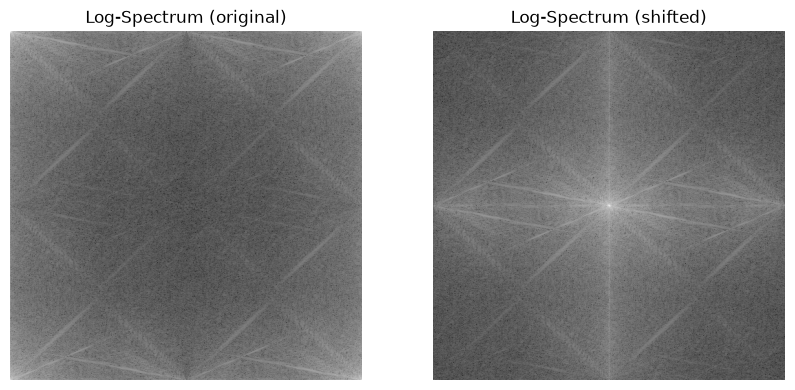

In [ ]:
F_X = np.fft.fft2(X)
spectrum = np.abs(F_X)**2

spectrum_shifted = np.fft.fftshift(spectrum)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.log10(spectrum), cmap='gray')
plt.title("Log-Spectrum (original)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.log10(spectrum_shifted), cmap='gray')
plt.title("Log-Spectrum (shifted)")
plt.axis('off')
plt.show()

3\. 
    a) Create a function `ideal_lowpass_filter` to filter $\mathbf{X}$ by an ideal low-pass filter. The filter preserves Fourier coefficients associated to frequencies below a cutoff specified in each direction ($\mathbf{f}_c = (f_{c,y}, f_{c,x})$), and sets others to zero. For simplicity, $f_{c,y}$ and $f_{c,x}$ can be expressed as a number of samples to be kept along each dimension (e.g., $\mathbf{f}_c = (50,50)$).

b) Display the filtered image for 2 different values of $\mathbf{f}_c$. What do you observe as the cutoff frequencies increase?
    
> Warning: beware the type of the array after `np.fft.fft2`, do not hesitate to specify the type if you make copies from this array
> ```python
> a = np.zeros((2,2), dtype=np.complex)
> ...
> ```

**Answer:**

b) As the cutoff frequencies decrease, the output image becomes blurrier because we retain less of the high-frequency information. Conversely, low cutoff frequencies heavily blur the image.

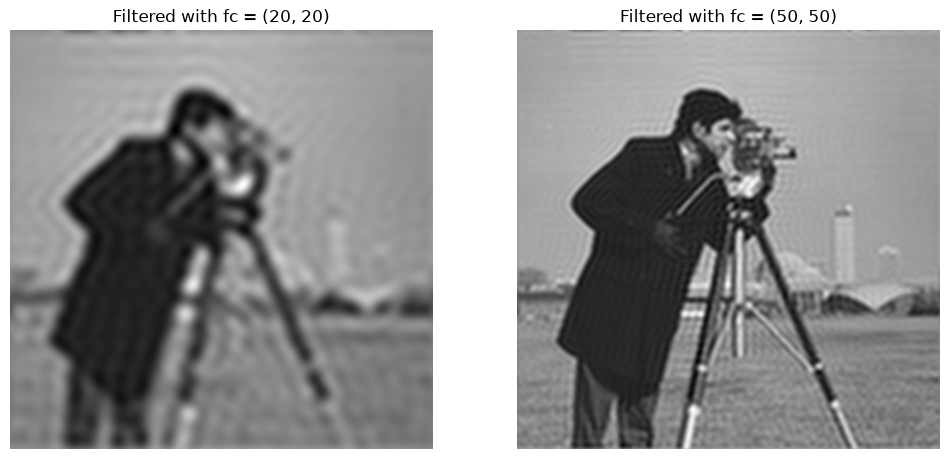

In [9]:
def ideal_lowpass_filter(X, fc):
    fcy, fcx = fc
    M, N = X.shape
    
    F_X = np.fft.fft2(X)
    F_X_shifted = np.fft.fftshift(F_X)
    
    # Create the ideal low-pass mask
    mask = np.zeros_like(F_X_shifted, dtype=float)
    cy, cx = M // 2, N // 2
    
    # The mask preserves frequencies within the cutoff
    y_min, y_max = max(0, cy - fcy), min(M, cy + fcy)
    x_min, x_max = max(0, cx - fcx), min(N, cx + fcx)
    mask[y_min:y_max, x_min:x_max] = 1.0
    
    F_X_filtered_shifted = F_X_shifted * mask
    F_X_filtered = np.fft.ifftshift(F_X_filtered_shifted)
    
    X_filtered = np.fft.ifft2(F_X_filtered).real
    return X_filtered

fc1 = (20, 20)
fc2 = (50, 50)

X_filtered1 = ideal_lowpass_filter(X, fc1)
X_filtered2 = ideal_lowpass_filter(X, fc2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(X_filtered1, cmap='gray')
plt.title(f"Filtered with fc = {fc1}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_filtered2, cmap='gray')
plt.title(f"Filtered with fc = {fc2}")
plt.axis('off')
plt.show()

4\. Let $\mathbf{H} \in \mathbb{R}^{M_2\times N_2}$ be a 2-D Gaussian kernel, obtained as the outer product of two 1-D Gaussian windows $\mathbf{w}_y \in \mathbb{R}^{M_2}$ and $\mathbf{w}_x \in \mathbb{R}^{N_2}$, of standard deviation $\sigma_y = 10$ and $\sigma_x = 10$, respectively:

\begin{equation}
    \mathbf{H} = \mathbf{w}_y \mathbf{w}_x^T.
\end{equation}

Let $M = M_1+M_2-1$ and $N =  N_1+N_2-1$. From the discrete convolution theorem, the linear convolution between $\mathbf{H}$ and $\mathbf{X}$ can be computed as follows

\begin{equation}
    \mathbf{X} \star \mathbf{H} = \mathcal{F}^{-1} \Big( \mathcal{F}\big(P_1(\mathbf{X})\big) \odot \mathcal{F}\big(P_2(\mathbf{H})\big) \Big) \in \mathbb{R}^{M\times N},
\end{equation}

where $P_i: \mathbb{R}^{M_i \times N_i} \rightarrow \mathbb{R}^{M \times N}$, $i \in \{1, 2\}$, are 0-padding operators, $\odot$ is the Hadamard (= term-wise) product, $\mathcal{F}^{-1}$ is the 2D discrete inverse Fourier transform.

Compute and display $\mathbf{X} \star \mathbf{H}$, for $M_2 = N_2 = 10$. What do you observe?

> Hint: 
> - the usual 0-padding procedure in image space consists in appending trailing zeros. For instance (in 1D), 0-padding a vector $\mathbf{x} \in \mathbb{R}^N_1$ to the size $N>N_1$ corresponds to creating the vector
\begin{bmatrix}
\mathbf{x} \\
\mathbf{0}_{N-N_1}
\end{bmatrix}
> - since the input images are real, $\mathcal{F}(\mathbf{x})$ and $\mathcal{F}(\mathbf{h})$ are Hermitian symmetric. In this case, a more efficient version of `np.fft.fft2` can be used, computing only quarter of the Fourier coefficients (half of the Fourier coefficients in each direction): [`np.fft.rfft2`](https://numpy.org/doc/stable/reference/generated/numpy.fft.rfft2.html?highlight=rfft#numpy.fft.rfft2). Its inverse, [`np.fft.irfft2`](https://numpy.org/doc/stable/reference/generated/numpy.fft.irfft2.html#numpy.fft.irfft2), also ensures that the output is real;
> - the 2D Gaussian window can be generated as the outer product of two 1D Gaussian windows (one window for each dimension);
> - you can take a look at [scipy.signal.windows.gaussian](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.windows.gaussian.html#scipy.signal.windows.gaussian) and [np.newaxis](https://numpy.org/doc/stable/reference/constants.html?highlight=newaxis#numpy.newaxis) (or `np.reshape` or built-in `np.outer`).

**Answer:**
The output image is blurred, as the convolution with a Gaussian kernel performs a low-pass filtering. We also observe that the resulting image size has darkened edges.

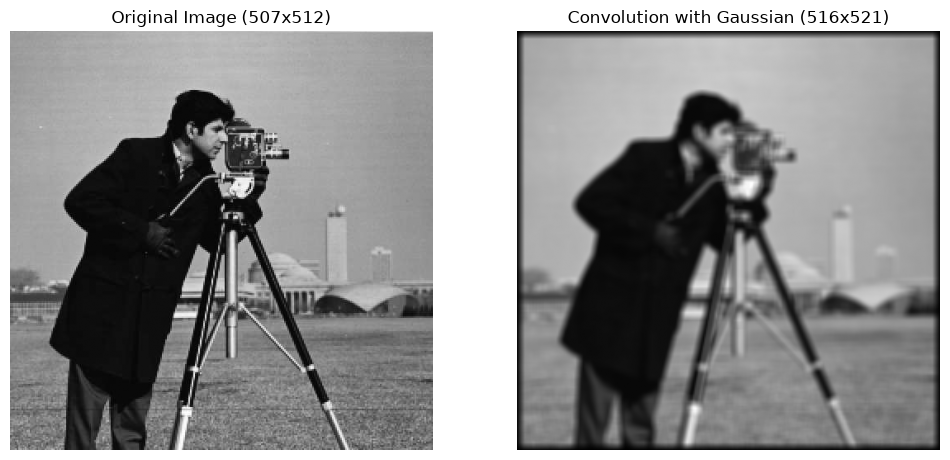

In [10]:
from scipy.signal.windows import gaussian

M1, N1 = X.shape
M2, N2 = 10, 10
sigma_y, sigma_x = 10, 10

wy = gaussian(M2, std=sigma_y)
wx = gaussian(N2, std=sigma_x)
H = np.outer(wy, wx)

M = M1 + M2 - 1
N = N1 + N2 - 1

# Pad X
P1_X = np.zeros((M, N))
P1_X[:M1, :N1] = X

# Pad H
P2_H = np.zeros((M, N))
P2_H[:M2, :N2] = H

# Linear convolution using rfft2
F_P1_X = np.fft.rfft2(P1_X)
F_P2_H = np.fft.rfft2(P2_H)

# Hadamard product
F_Conv = F_P1_X * F_P2_H

# Inverse transform
X_conv_H = np.fft.irfft2(F_Conv, s=(M, N))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(X, cmap='gray')
plt.title(f"Original Image ({M1}x{N1})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_conv_H, cmap='gray')
plt.title(f"Convolution with Gaussian ({M}x{N})")
plt.axis('off')
plt.show()